In [3]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib as plt


In [6]:
data = datasets.cifar10.load_data()
data

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 470s 3us/step


((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

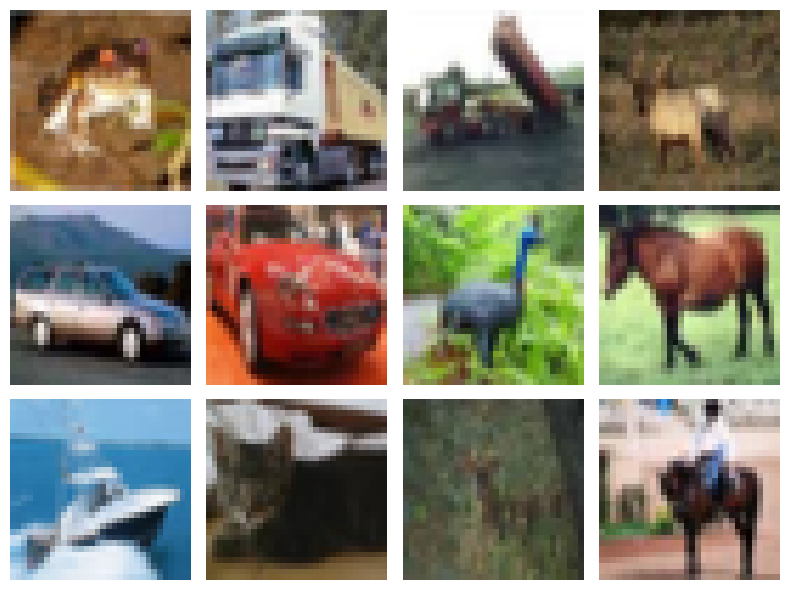

In [40]:
import matplotlib.pyplot as plt
from tensorflow.keras import datasets

# Load data
data = datasets.cifar10.load_data()

(x_train, y_train), (x_test, y_test) = data

# Plot images
plt.figure(figsize=(8, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [39]:
(x_train,y_train),(X_test,y_train) = data 

In [14]:
X_train = x_train / 255.0
X_test  = x_test / 255.0


In [15]:
x_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [38]:
y_train = y_train.flatten()
y_test  = y_test.flatten()


In [31]:
cnn_model = models.Sequential()
cnn_model.add(
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3))
)
cnn_model.add(layers.MaxPooling2D(2 , 2))


cnn_model.add(
    layers.Conv2D(64, (3, 3), activation='relu')
)
cnn_model.add(layers.MaxPooling2D(2 , 2))


cnn_model.add(
    layers.Conv2D(64, (3, 3), activation='relu')
)
cnn_model.add(layers.Flatten())  


cnn_model.add(layers.Dense(64,activation='relu'))
cnn_model.add(layers.Dense(10,activation='softmax'))
print(cnn_model.summary()) 




Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [42]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [43]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.3905 - loss: 1.7453 - val_accuracy: 0.4542 - val_loss: 1.5123
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5266 - loss: 1.3348 - val_accuracy: 0.5642 - val_loss: 1.2406
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5862 - loss: 1.1850 - val_accuracy: 0.5861 - val_loss: 1.1893
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6236 - loss: 1.0849 - val_accuracy: 0.5762 - val_loss: 1.2272
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.6522 - loss: 1.0006 - val_accuracy: 0.6261 - val_loss: 1.0884
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6769 - loss: 0.9336 - val_accuracy: 0.6401 - val_loss: 1.0469
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6994 - loss: 0.8693 - val_accuracy: 0.6508 - val_loss: 1.0838
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7149 -

In [44]:
history_cnn =cnn_model.fit(x_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.8005 - loss: 0.5716 - val_accuracy: 0.8062 - val_loss: 0.5694
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.8200 - loss: 0.5166 - val_accuracy: 0.7892 - val_loss: 0.5937
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8307 - loss: 0.4871 - val_accuracy: 0.7744 - val_loss: 0.6747
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.8396 - loss: 0.4545 - val_accuracy: 0.7609 - val_loss: 0.7342
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.8508 - loss: 0.4273 - val_accuracy: 0.7548 - val_loss: 0.7763
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.8584 - loss: 0.4044 - val_accuracy: 0.7365 - val_loss: 0.8860
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8697 - loss: 0.3667 - val_accuracy: 0.7301 - val_loss: 0.9452
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.8714 - loss: 0.3608 - 

In [46]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print(f"Test Accuracy: {cnn_acc}")
print(f"Test Loss: {cnn_loss}")


313/313 - 3s - 10ms/step - accuracy: 0.6561 - loss: 1.6348
Test Accuracy: 0.6560999751091003
Test Loss: 1.6348069906234741


In [47]:
class_names=['airplane','automation','bird','cat','frog','horse','ship','truck']

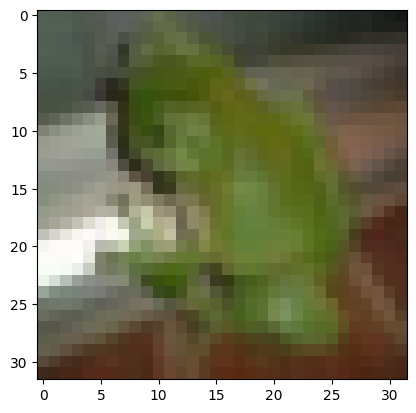

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
predicted class: ship


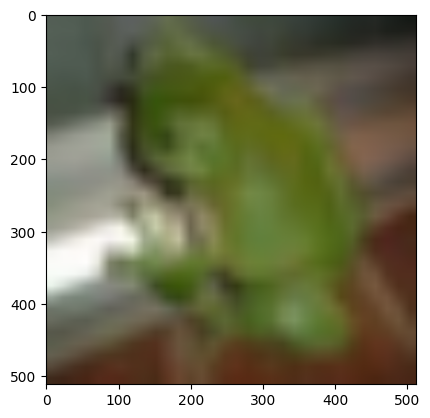

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# pick an index
index = 7

# get image
img = x_test[index]

# display image
plt.imshow(img)
#plt.axis('off')
plt.show()

display_img=cv2.resize(img, (512, 512))
plt.imshow(display_img)

#predict the image 
img=np.expand_dims(img,axis=0)
prediction = cnn_model.predict(img)
prediction_class = np.argmax(prediction[0])
print(f"predicted class: {class_names[prediction_class]}")

In [75]:
#predict thre class_ name by real image 
image_path = "sample2.jpeg"
img = cv2.imread(image_path)

#conert bgr to rgb
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#resize the image to 32x32 pixels cifar-10 image size is 32x32
img_resized = cv2.resize(img, (32, 32))

#normailize the pixel values
img_resized = img_resized / 255.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Predicted class: frog


(np.float64(-0.5), np.float64(512.5), np.float64(511.5), np.float64(-0.5))

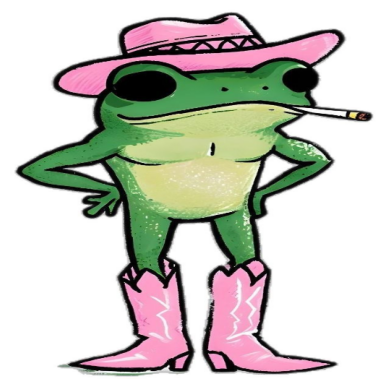

In [76]:
#ecxpand dimentions to match the model input 
img_input = np.expand_dims(img_resized, axis=0)  

#predict the class
predictions = cnn_model.predict(img_input)
predicted_class = np.argmax(predictions[0])
print(f"Predicted class: {class_names[predicted_class]}")

#show the image
plt.imshow(cv2.resize(img, (513, 512)))
plt.axis('off')

In [77]:
cnn_model.save("cifar10_cnn_model.h5")
